In [48]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from imblearn.over_sampling import SMOTE

In [7]:
fp = r"C:\Users\balaj\OneDrive\Desktop\disease prediction models\good dataset\heart_disease.csv".replace("\\","/")
df = pd.read_csv(fp)

In [8]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,1,1,140,289,0,1,172,1,0.0,1,0
1,49,2,2,160,180,0,1,156,1,1.0,2,1
2,37,1,1,130,283,0,2,98,1,0.0,1,0
3,48,2,3,138,214,0,1,108,2,1.5,2,1
4,54,1,2,150,195,0,1,122,1,0.0,1,0


In [10]:
df['HeartDisease'].value_counts()

HeartDisease
1    508
0    410
Name: count, dtype: int64

In [11]:
df.describe()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,1.210240,2.452070,132.396514,198.799564,0.233115,1.603486,136.809368,1.404139,0.887364,1.638344,0.553377
std,9.432617,0.407701,0.851832,18.514154,109.384145,0.423046,0.805968,25.460334,0.490992,1.066570,0.607056,0.497414
min,28.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,60.000000,1.000000,-2.600000,1.000000,0.000000
25%,47.000000,1.000000,2.000000,120.000000,173.250000,0.000000,1.000000,120.000000,1.000000,0.000000,1.000000,0.000000
50%,54.000000,1.000000,3.000000,130.000000,223.000000,0.000000,1.000000,138.000000,1.000000,0.600000,2.000000,1.000000
75%,60.000000,1.000000,3.000000,140.000000,267.000000,0.000000,2.000000,156.000000,2.000000,1.500000,2.000000,1.000000
max,77.000000,2.000000,4.000000,200.000000,603.000000,1.000000,3.000000,202.000000,2.000000,6.200000,3.000000,1.000000


<Axes: >

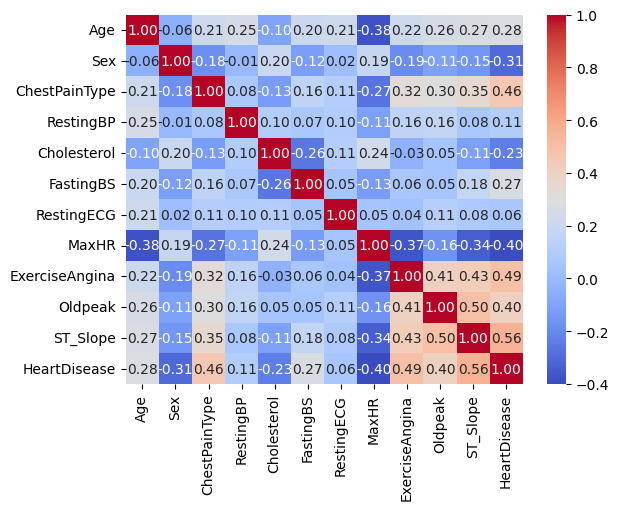

In [13]:
sb.heatmap(data=df.corr(), cmap="coolwarm", fmt=".2f", annot=True)

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
 [Text(0, 0, 'Age'),
  Text(1, 0, 'Sex'),
  Text(2, 0, 'ChestPainType'),
  Text(3, 0, 'RestingBP'),
  Text(4, 0, 'Cholesterol'),
  Text(5, 0, 'FastingBS'),
  Text(6, 0, 'RestingECG'),
  Text(7, 0, 'MaxHR'),
  Text(8, 0, 'ExerciseAngina'),
  Text(9, 0, 'Oldpeak'),
  Text(10, 0, 'ST_Slope'),
  Text(11, 0, 'HeartDisease')])

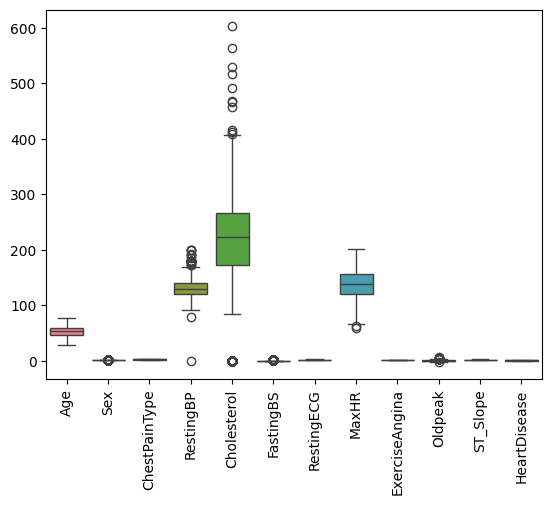

In [16]:
sb.boxplot(df)
plt.xticks(rotation=90)

In [17]:
df.shape

(918, 12)

In [35]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

bounds = {}
for col in numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    bounds[col] = (lower, upper)

mask = pd.Series(True, index=df.index)
for col, (lower, upper) in bounds.items():
    mask &= (df[col] >= lower) & (df[col] <= upper)

df_clean = df[mask].copy()

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
 [Text(0, 0, 'Age'),
  Text(1, 0, 'Sex'),
  Text(2, 0, 'ChestPainType'),
  Text(3, 0, 'RestingBP'),
  Text(4, 0, 'Cholesterol'),
  Text(5, 0, 'FastingBS'),
  Text(6, 0, 'RestingECG'),
  Text(7, 0, 'MaxHR'),
  Text(8, 0, 'ExerciseAngina'),
  Text(9, 0, 'Oldpeak'),
  Text(10, 0, 'ST_Slope'),
  Text(11, 0, 'HeartDisease')])

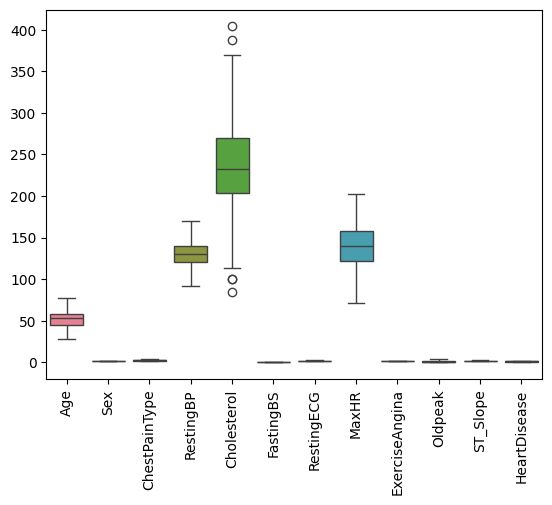

In [36]:
sb.boxplot(df_clean)
plt.xticks(rotation=90)

In [37]:
df_clean.shape

(436, 12)

In [18]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

In [19]:
x = df.drop('HeartDisease', axis=1)
y = df['HeartDisease']

In [56]:
def run_models_train_test_table(X, y):
    x_train, x_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )
    smote = SMOTE(random_state=42)

    x_train_smote, y_train_smote = smote.fit_resample(
        x_train,
        y_train
    )
    models = {
        "Logistic Regression": Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=1000))
        ]),
        "Decision Tree": DecisionTreeClassifier(random_state=42),
        "Random Forest": RandomForestClassifier(random_state=42),
        "Gradient Boosting": GradientBoostingClassifier(random_state=42),
        "SVM": Pipeline([
            ("scaler", StandardScaler()),
            ("model", SVC())
        ]),
        "KNN": Pipeline([
            ("scaler", StandardScaler()),
            ("model", KNeighborsClassifier())
        ]),
        "Naive Bayes": Pipeline([
            ("scaler", StandardScaler()),
            ("model", GaussianNB())
        ])
    }

    results = []

    for name, model in models.items():
        model.fit( x_train_smote, y_train_smote)

        train_pred = model.predict(x_train_smote)
        test_pred = model.predict(x_test)

        train_acc = accuracy_score(y_train_smote, train_pred) * 100
        test_acc = accuracy_score(y_test, test_pred) * 100

        results.append({
            "Model": name,
            "Train Accuracy (%)": train_acc,
            "Test Accuracy (%)": test_acc,
            "Gap (%)": train_acc - test_acc
        })

    results_df = pd.DataFrame(results).sort_values(
        by="Test Accuracy (%)",
        ascending=False
    ).reset_index(drop=True)

    return results_df

In [57]:
run_models_train_test_table(x,y)

,Model,Train Accuracy (%),Test Accuracy (%),Gap (%)
0,Random Forest,100.000000,89.673913,10.326087
1,KNN,90.394089,88.586957,1.807132
2,Naive Bayes,85.221675,88.043478,-2.821803
3,SVM,89.039409,87.500000,1.539409
4,Gradient Boosting,94.950739,87.500000,7.450739
5,Logistic Regression,86.206897,86.956522,-0.749625
6,Decision Tree,100.000000,80.978261,19.021739


In [29]:
def run_models_with_cv(X, y, folds=5):
    
    # Keeps target-class ratio similar in each fold
    cv = StratifiedKFold(
        n_splits=folds,
        shuffle=True,
        random_state=42
    )
    
    models = {
        "Logistic Regression": Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=1000))
        ]),
        
        "Decision Tree": DecisionTreeClassifier(
            random_state=42
        ),
        
        "Random Forest": RandomForestClassifier(
            random_state=42
        ),
        
        "Gradient Boosting": GradientBoostingClassifier(
            random_state=42
        ),
        
        "SVM": Pipeline([
            ("scaler", StandardScaler()),
            ("model", SVC())
        ]),
        
        "KNN": Pipeline([
            ("scaler", StandardScaler()),
            ("model", KNeighborsClassifier())
        ]),
        
        "Naive Bayes": Pipeline([
            ("scaler", StandardScaler()),
            ("model", GaussianNB())
        ])
    }
    
    results = []
    
    for name, model in models.items():
        
        scores = cross_val_score(
            model,
            X,
            y,
            cv=cv,
            scoring="accuracy"
        )
        
        results.append({
            "Model": name,
            "Mean Accuracy (%)": scores.mean() * 100,
            "Std (%)": scores.std() * 100,
            "Fold Scores (%)": np.round(scores * 100, 2)
        })
        
        print("=" * 55)
        print(f"Model: {name}")
        print(f"Fold Accuracies: {np.round(scores * 100, 2)}")
        print(f"Mean Accuracy: {scores.mean() * 100:.2f}%")
        print(f"Standard Deviation: {scores.std() * 100:.2f}%")
    
    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values(
        by="Mean Accuracy (%)",
        ascending=False
    ).reset_index(drop=True)
    
    return results_df

In [30]:
run_models_with_cv(x,y)

Model: Logistic Regression
Fold Accuracies: [87.5  83.7  84.24 85.25 84.7 ]
Mean Accuracy: 85.08%
Standard Deviation: 1.32%
Model: Decision Tree
Fold Accuracies: [86.41 78.8  72.83 71.58 79.78]
Mean Accuracy: 77.88%
Standard Deviation: 5.34%
Model: Random Forest
Fold Accuracies: [90.22 86.96 83.7  87.43 83.61]
Mean Accuracy: 86.38%
Standard Deviation: 2.49%
Model: Gradient Boosting
Fold Accuracies: [89.13 86.41 85.87 88.52 84.15]
Mean Accuracy: 86.82%
Standard Deviation: 1.81%
Model: SVM
Fold Accuracies: [90.22 85.33 82.61 86.34 86.34]
Mean Accuracy: 86.17%
Standard Deviation: 2.44%
Model: KNN
Fold Accuracies: [87.5  86.96 80.98 86.89 87.98]
Mean Accuracy: 86.06%
Standard Deviation: 2.57%
Model: Naive Bayes
Fold Accuracies: [85.33 84.78 83.7  83.06 85.79]
Mean Accuracy: 84.53%
Standard Deviation: 1.01%


,Model,Mean Accuracy (%),Std (%),Fold Scores (%)
0,Gradient Boosting,86.818128,1.812486,"[89.13, 86.41, 85.87, 88.52, 84.15]"
1,Random Forest,86.381563,2.492457,"[90.22, 86.96, 83.7, 87.43, 83.61]"
2,SVM,86.165954,2.442677,"[90.22, 85.33, 82.61, 86.34, 86.34]"
3,KNN,86.059634,2.571448,"[87.5, 86.96, 80.98, 86.89, 87.98]"
4,Logistic Regression,85.076028,1.315457,"[87.5, 83.7, 84.24, 85.25, 84.7]"
5,Naive Bayes,84.531361,1.014672,"[85.33, 84.78, 83.7, 83.06, 85.79]"
6,Decision Tree,77.881920,5.337705,"[86.41, 78.8, 72.83, 71.58, 79.78]"


In [43]:
def run_all_models_metrics(X, y, test_size=0.2, random_state=42):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        random_state=random_state,
        stratify=y
    )

    models = {
        "Logistic Regression": Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=1000))
        ]),
        "Decision Tree": DecisionTreeClassifier(random_state=random_state),
        "Random Forest": RandomForestClassifier(random_state=random_state),
        "Gradient Boosting": GradientBoostingClassifier(random_state=random_state),
        "SVM": Pipeline([
            ("scaler", StandardScaler()),
            ("model", SVC(probability=True))
        ]),
        "KNN": Pipeline([
            ("scaler", StandardScaler()),
            ("model", KNeighborsClassifier())
        ]),
        "Naive Bayes": Pipeline([
            ("scaler", StandardScaler()),
            ("model", GaussianNB())
        ])
    }

    results = []

    for name, model in models.items():
        model.fit(X_train, y_train)

        train_pred = model.predict(X_train)
        test_pred = model.predict(X_test)

        train_acc = accuracy_score(y_train, train_pred) * 100
        test_acc = accuracy_score(y_test, test_pred) * 100
        gap = train_acc - test_acc

        rec = recall_score(y_test, test_pred, zero_division=0)
        f1 = f1_score(y_test, test_pred, zero_division=0)

        if hasattr(model, "predict_proba"):
            y_prob = model.predict_proba(X_test)[:, 1]
        else:
            y_prob = model.decision_function(X_test)

        roc_auc = roc_auc_score(y_test, y_prob) * 100

        results.append({
            "Model": name,
            "Accuracy (%)": test_acc,
            "Recall": rec,
            "F1": f1,
            "ROC-AUC (%)": roc_auc,
            "Gap (%)": gap
        })

    results_df = pd.DataFrame(results).sort_values(
        by="Accuracy (%)",
        ascending=False
    ).reset_index(drop=True)

    return results_df

In [44]:
run_all_models_metrics(x,y)

C:\Users\balaj\AppData\Roaming\Python\Python311\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,Model,Accuracy (%),Recall,F1,ROC-AUC (%),Gap (%)
0,KNN,89.130435,0.921569,0.903846,92.969871,-0.165857
1,Gradient Boosting,88.586957,0.901961,0.897561,93.735055,5.418493
2,Random Forest,88.586957,0.901961,0.897561,93.203013,11.413043
3,Naive Bayes,88.586957,0.921569,0.899522,93.280727,-4.118292
4,Logistic Regression,87.500000,0.911765,0.889952,89.825442,-2.213896
5,SVM,86.413043,0.921569,0.882629,92.384027,2.142815
6,Decision Tree,81.521739,0.794118,0.826531,81.779053,18.478261


In [45]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')